> **SUPERSEDED LINE.** This notebook renders the committed evidence for the
> book-model cop line — `models/cop_recurrent_champion.pt` (sha256 `b9e74b7a…`) — which is **no longer
> the shipped champion**. The Step-0 scent negotiation with imreeyal locked
> `subtractive_chebyshev_v1` on 2026-08-09/10 and the movement stack was rebuilt.
> For the current champion and its evidence see `docs/RL_RESEARCH_REPORT_20260810.md`
> and `models/MANIFEST.json`. The data files rendered here are kept unchanged as the
> historical record of that line.


# Exact release strategy analysis
This notebook renders the committed machine-readable tournament, ablation, sensitivity, learning-curve, and curriculum evidence. It does not generate synthetic metrics.

In [1]:
import json
from pathlib import Path

import pandas as pd

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
rl = ROOT / "results" / "rl"
analysis = json.loads((rl / "strategy_analysis.json").read_text())
analysis["role"], analysis["artifact_sha256"], analysis["environment"]

('cop',
 'b9e74b7a13ca461484f2b47046eeecf8d393cb8d64b7cdd51d2915b714c21268',
 {'python': '3.13.14',
  'platform': 'Windows-11-10.0.26200-SP0',
  'processor': 'Intel64 Family 6 Model 158 Stepping 13, GenuineIntel',
  'torch': '2.13.0+cpu',
  'numpy': '2.5.1',
  'wall_seconds': 261.51061780005693})

In [2]:
ablations = pd.read_csv(rl / "ablations.csv")
sensitivity = pd.read_csv(rl / "sensitivity.csv")
curves = pd.read_csv(rl / "learning_curves.csv")
curriculum = pd.read_csv(rl / "curriculum_comparison.csv")
display(ablations, sensitivity, curves, curriculum)

,variant,note,series,gamelets,win_rate,series_win_rate,official_role_score,official_opponent_score,score_differential,worst_family_win_rate,average_turns,illegal_action_rate,p99_inference_ms,technical_failures
0,full_release,exact release inference,50,300,0.820000,0.98,5190,1770,3420,0.600000,15.263333,0.000000,0.547384,0
1,strongest_heuristic,local belief heuristic,50,300,0.726667,0.96,4770,1910,2860,0.466667,18.043333,0.000000,NaN,0
2,scent_only_no_belief,belief tensor removed,50,300,0.866667,0.98,5400,1700,3700,0.500000,13.660000,0.000000,0.569635,0
3,belief_only_no_scent,scent tensor removed,50,300,0.360000,0.54,3120,2460,660,0.000000,27.573333,0.000000,0.547845,0
4,stateless,recurrent state reset every turn,50,300,0.803333,1.00,5115,1795,3320,0.600000,15.163333,0.000000,0.585032,0
5,no_legal_mask,offline unsafe-mask ablation,50,300,0.656667,0.96,4455,2015,2440,0.433333,19.600000,0.442857,0.544646,0
6,no_barrier_actions,PLACE actions removed,50,300,0.836667,0.98,5265,1745,3520,0.466667,15.493333,0.000000,0.558195,0
7,language_off,measured invariant: language policy cannot ent...,50,300,0.820000,0.98,5190,1770,3420,0.600000,15.263333,0.000000,0.547384,0


,inference_mode,temperature,win_rate,series_win_rate,official_role_score,score_differential,worst_family_win_rate,illegal_action_rate,p99_inference_ms
0,argmax,0.00,0.82,0.98,5190,3420,0.600000,0.0,0.547384
1,controlled_stochastic,0.25,0.80,0.98,5100,3300,0.600000,0.0,0.555952
2,controlled_stochastic,0.50,0.80,1.00,5100,3300,0.600000,0.0,0.544800
3,controlled_stochastic,0.75,0.73,1.00,4785,2880,0.533333,0.0,0.565465


,training_episodes,held_out_gamelets,capture_rate,series_win_rate,official_role_score,official_opponent_score,worst_family_rate,artifact_sha256,promotion_passed
0,2400,1800,0.848333,0.980000,31905,10365,0.461111,1c6f85bed3ba754d1daa38aa394b455d605fe176843653...,False
1,3200,1800,0.853889,0.986667,32055,10315,0.483333,bc389ac12a438fbab8207b187d850b3bf44ba07e378c53...,False
2,4800,1800,0.848333,0.986667,31905,10365,0.494444,89e600846d95a0d4a5c9e62c9aa8524cd50086edc5c109...,False
3,8800,1800,0.833333,0.990000,31500,10500,0.522222,36abc101ec496ca546e1ca8cf98a27899048928022f659...,False
4,11800,1800,0.829444,0.993333,31395,10535,0.577778,b9e74b7a13ca461484f2b47046eeecf8d393cb8d64b7cd...,True


,training_regime,artifact_sha256,continuation_episodes,training_families,held_out_gamelets,win_rate,series_win_rate,official_role_score,official_opponent_score,score_differential,worst_family_win_rate
0,population_release,b9e74b7a13ca461484f2b47046eeecf8d393cb8d64b7cd...,0,10,300,0.82,0.98,5190,1770,3420,0.6
1,single_checkpoint_self_play,74bdda0b6887c69c0ab530aa7b3c86fae3fb9a06c12e4b...,800,1,300,0.80,0.98,5100,1800,3300,0.6


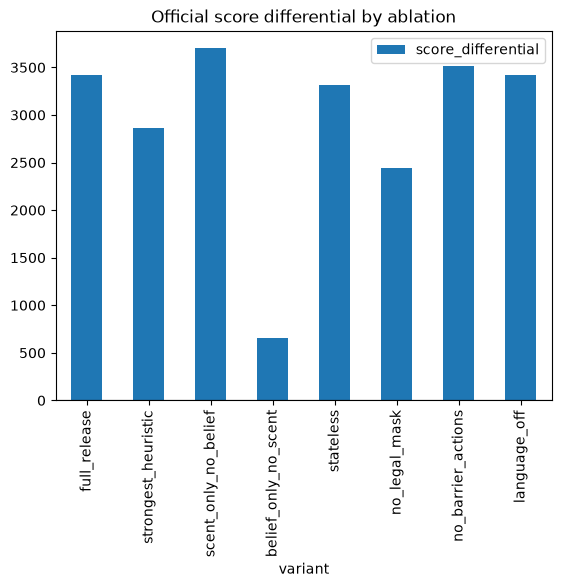

In [3]:
ax = ablations.plot.bar(
    x="variant",
    y="score_differential",
    title="Official score differential by ablation",
)
ax.axhline(0, color="black", linewidth=0.8)